# Tutorial 110: Unconditional Flow Matching — Generating PBMC Cells from Noise

In Tutorial 100 both source and target were synthetic cell populations. Here we do:

* __Source__:  Gaussian noise 
* __Target__:  PBMC single-cell data


In [1]:
%load_ext autoreload
%autoreload 2

## Contents

1. **Section 1**: Inline Components
2. **Section 2**: Preprocess PBMC Data
3. **Section 3**: DataLoader Setup
4. **Section 4**: Model Setup
5. **Section 5**: Training
6. **Section 6**: Inference
7. **Section 7**: ODE Trajectories

In [2]:
import numpy as np
import torch
import scanpy as sc
import matplotlib.pyplot as plt

from sc_flow.trainer._trainer import FlowTrainer
from sc_flow.backends.torch.nn import MLPUnconditionalVF
from sc_flow.backends.torch.coupling import independent_coupling
from sc_flow.backends.torch.probability_paths import LinearGaussianProbabilityPath
from sc_flow.backends.torch.solvers import ODESolver
from sc_flow.preprocessing import PCATransform, ZScoreTransform
from sc_flow import methods as basemethods

SEED = 40
np.random.seed(SEED)
torch.manual_seed(SEED)

## Section 1: Inline Components

`BaseMethod` is defined inline because this branch does not have it. This section will be removed later and everything else will bechanged accordingly.

In [3]:
class BaseMethod(basemethods.FlowMatching):
    """Minimal flow matching implementation used in this tutorial."""

    def __init__(self, vf, probability_path, time_sampler, match_fn, opt=None, **kwargs):
        self.vf = vf
        self.probability_path = probability_path
        self.time_sampler = time_sampler
        self.match_fn = match_fn
        self.opt = opt(self.vf.parameters(), lr=5e-4)
        self._is_trained = False
        self._vf_step_fn = self._build_vf_step_fn()

    def _build_vf_step_fn(self):
        def vf_step_fn(time, source, target, conditions):
            def loss_fn(t, src, tgt, cond):
                x_t = self.probability_path.compute_xt(t, src, tgt)
                v_t = self.vf(t, x_t, cond, src)
                u_t = self.probability_path.compute_ut(t, x_t, src, tgt)
                return torch.mean((v_t - u_t) ** 2)

            self.opt.zero_grad()
            loss = loss_fn(time, source, target, conditions)
            loss.backward()
            self.opt.step()
            return loss

        return vf_step_fn

    def step_fn(self, batch):
        """Compute one training step and return the loss tensor."""
        source = batch["src_cell_data"]
        target = batch["tgt_cell_data"]
        time = self.time_sampler(source.shape[0])
        src_ixs, tgt_ixs = self.match_fn(source, target)
        return self._vf_step_fn(time, source[src_ixs], target[tgt_ixs], conditions=None)

    def train_step(self, batch, prng_ley=None):
        """Run one gradient step and return the scalar loss."""
        return float(self.step_fn(batch).cpu())

    def predict(self, x):
        """Integrate ODE from t=0 (noise) to t=1 (generated cells)."""
        time = torch.linspace(0.0, 1.0, 101)
        solver = ODESolver(dynamics=self.vf, method="euler", vf_kwargs={"condition_dict": None})
        return solver.solve(source=x, time=time, rtol=1e-6, atol=1e-7, return_trajectory=False)

    def predict_trajectory(self, x, n_steps: int = 20):
        """Return full ODE trajectory. Shape: (n_steps, n_cells, n_dims)."""
        time = torch.linspace(0.0, 1.0, n_steps)
        solver = ODESolver(dynamics=self.vf, method="euler", vf_kwargs={"condition_dict": None})
        return solver.solve(source=x, time=time, rtol=1e-5, atol=1e-6, return_trajectory=True)


def uniform_time_sampler(n: int) -> torch.Tensor:
    """Sample n uniform random times in [0, 1]."""
    return torch.rand(size=(n,))

## Section 2: Preprocess PBMC Data

The dataset contains 10,000 PBMC cells profiled across 2,000 highly variable genes.
We reduce to 50 principal components — this is the space the model will work in.

In [4]:
DATA_PATH = r"C:\Users\HP\Documents\munich_work\CellFlow\pbmc_small.h5ad"
adata = sc.read_h5ad(DATA_PATH)
print(adata)

AnnData object with n_obs × n_vars = 10000 × 2000
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'cytokine_family'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'donor_embeddings', 'esm2_embeddings', 'hvg', 'log1p'


In [5]:
N_COMPONENTS = 50

# PCATransform expects a dense (n_samples, n_features) array
X_raw = adata.X.toarray()

pca = PCATransform(n_components=N_COMPONENTS)
X_pca = pca.fit_transform(X_raw).astype(np.float32)  # (10000, 50), float64 internally

# ZScoreTransform: zero mean, unit variance per PC so scale matches Gaussian noise
# I am doing this mainly for clearer visualization of PCA space
zscore = ZScoreTransform()
X_pca = zscore.fit_transform(X_pca).astype(np.float32)

print(f"PCA shape: {X_pca.shape}")
print(f"PC1 range: [{X_pca[:, 0].min():.2f}, {X_pca[:, 0].max():.2f}]")

PCA shape: (10000, 50)
PC1 range: [-0.62, 13.57]


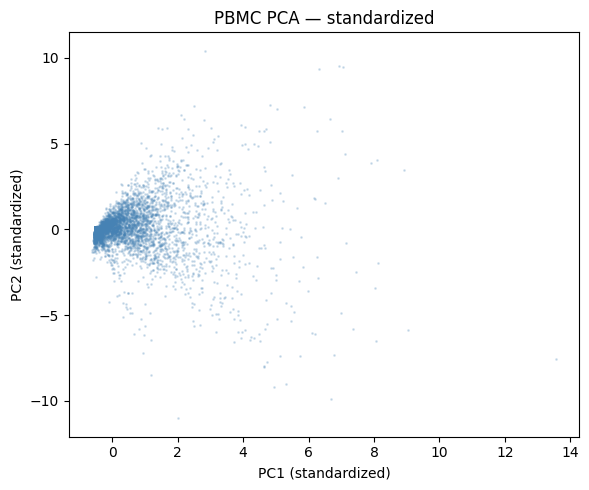

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_pca[:, 0], X_pca[:, 1], s=1, alpha=0.2, color="steelblue")
ax.set_xlabel("PC1 (standardized)")
ax.set_ylabel("PC2 (standardized)")
ax.set_title("PBMC PCA — standardized")
plt.tight_layout()
plt.show()

## Section 3: DataLoader Setup
Each training step draws:
- **Source**: fresh Gaussian noise vectors — one per cell in the mini-batch
- **Target**: randomly sampled real PBMC cells

> I dont really know how to use DataManager for these different types of data. For now, just a basic loader I have used.

In [7]:
class NoiseToCellLoader:
    """Pairs Gaussian noise (source) with randomly sampled real cells (target)."""

    def __init__(self, X_target: np.ndarray, batch_size: int):
        self.X_target = torch.tensor(X_target, dtype=torch.float32)
        self.batch_size = batch_size
        self.n_dim = X_target.shape[1]

    def sample(self, _=None) -> dict:
        """Return a batch with noise source and sampled target cells."""
        noise = torch.randn(self.batch_size, self.n_dim)
        idx = torch.randint(0, len(self.X_target), (self.batch_size,))
        return {
            "src_cell_data": noise,
            "tgt_cell_data": self.X_target[idx],
        }


train_loader = NoiseToCellLoader(X_pca, batch_size=256)

batch = train_loader.sample()
print("src (noise):", batch["src_cell_data"].shape)
print("tgt (cells):", batch["tgt_cell_data"].shape)

src (noise): torch.Size([256, 50])
tgt (cells): torch.Size([256, 50])


## Section 4: Model Setup

In [8]:
STATE_DIM = N_COMPONENTS  # 50

vf = MLPUnconditionalVF(
    state_dim=STATE_DIM,
    encode_state=True,
    encode_time=True,
    time_features_id="torch-cfm",
    state_encoder_mlp_kwargs={"hidden_dims": (64,)},
    time_encoder_mlp_kwargs={"hidden_dims": (32,)},
    vf_decoder_mlp_kwargs={"hidden_dims": (128, 128)},
)

g = torch.Generator()
g.manual_seed(4)
model = BaseMethod(
    vf=vf,
    probability_path=LinearGaussianProbabilityPath(sigma=0.01, prng=g),
    time_sampler=uniform_time_sampler,
    match_fn=independent_coupling,
    opt=torch.optim.AdamW,
)
trainer = FlowTrainer(method=model, require_prng=False)
print("Model ready.")

Model ready.


## Section 5: Training

In [9]:
trainer.fit(train_dataloader=train_loader, num_iterations=5_000, valid_freq=5_001)

  0%|          | 0/5000 [00:00<?, ?it/s]Validation step requires validation data. Please prepare validation data with `model.prepare_validation_data()` method.
C:\Users\HP\AppData\Local\Temp\ipykernel_6792\2390608040.py:34: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  return float(self.step_fn(batch).cpu())
100%|██████████| 5000/5000 [00:44<00:00, 112.23it/s]


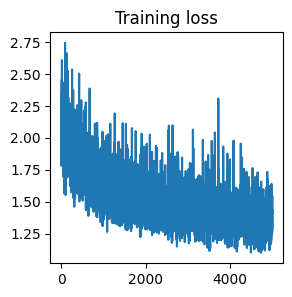

In [10]:
trainer.plot_training_logs()
plt.title("Training loss")
plt.show()

## Section 6: Inference

We sample fresh Gaussian noise and predict its movement.
The output should be synthetic cells whose distribution closely matches the real PBMC data.

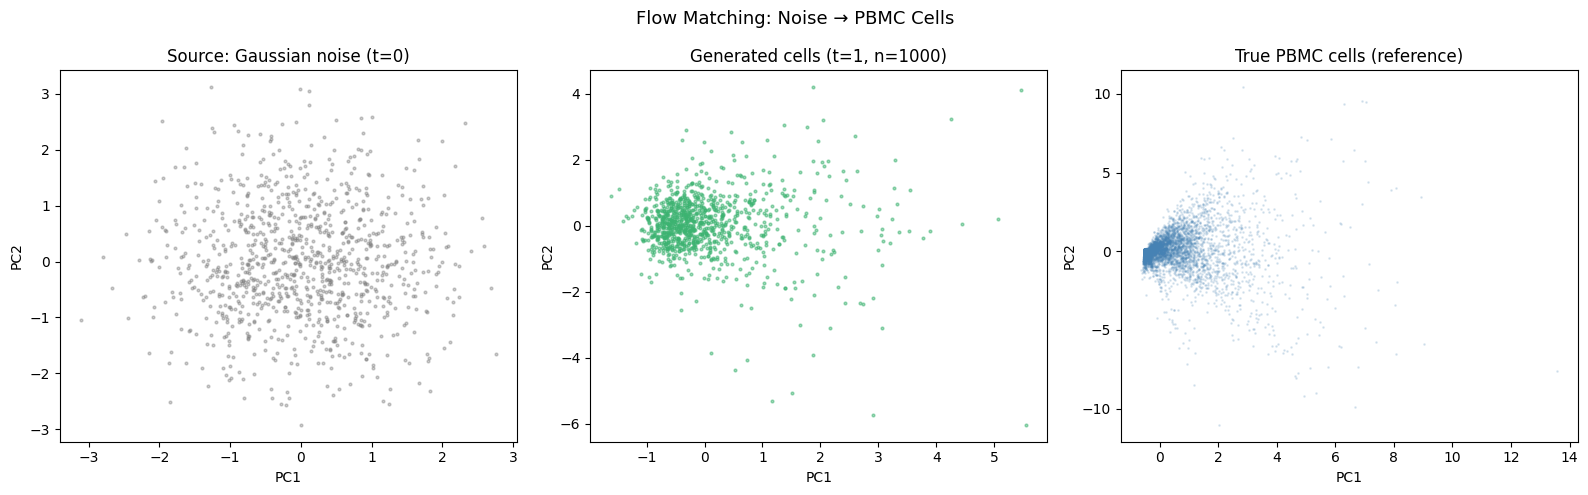

In [11]:
N_GENERATE = 1000
noise_input = torch.randn(N_GENERATE, STATE_DIM)

model.vf.eval()
with torch.no_grad():
    generated = model.predict(noise_input)

gen_np = generated.numpy()
noise_np = noise_input.numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(noise_np[:, 0], noise_np[:, 1], s=4, alpha=0.4, color="gray")
axes[0].set_title("Source: Gaussian noise (t=0)")

axes[1].scatter(gen_np[:, 0], gen_np[:, 1], s=4, alpha=0.5, color="mediumseagreen")
axes[1].set_title(f"Generated cells (t=1, n={N_GENERATE})")

axes[2].scatter(X_pca[:, 0], X_pca[:, 1], s=1, alpha=0.15, color="steelblue")
axes[2].set_title("True PBMC cells (reference)")

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.suptitle("Flow Matching: Noise → PBMC Cells", fontsize=13)
plt.tight_layout()
plt.show()

## Section 7: ODE Trajectories (PCA)

Here, we visualise how 30 input points travel through PCA space as the ODE integrates
from t=0 to t=1. Since the model operates in 50-dim space we project the
trajectory down to PC1 vs PC2 for plotting.

Note: Since we are plotting 50-dim points in 2D graph, it would be just an estimate how the actual movement happens.

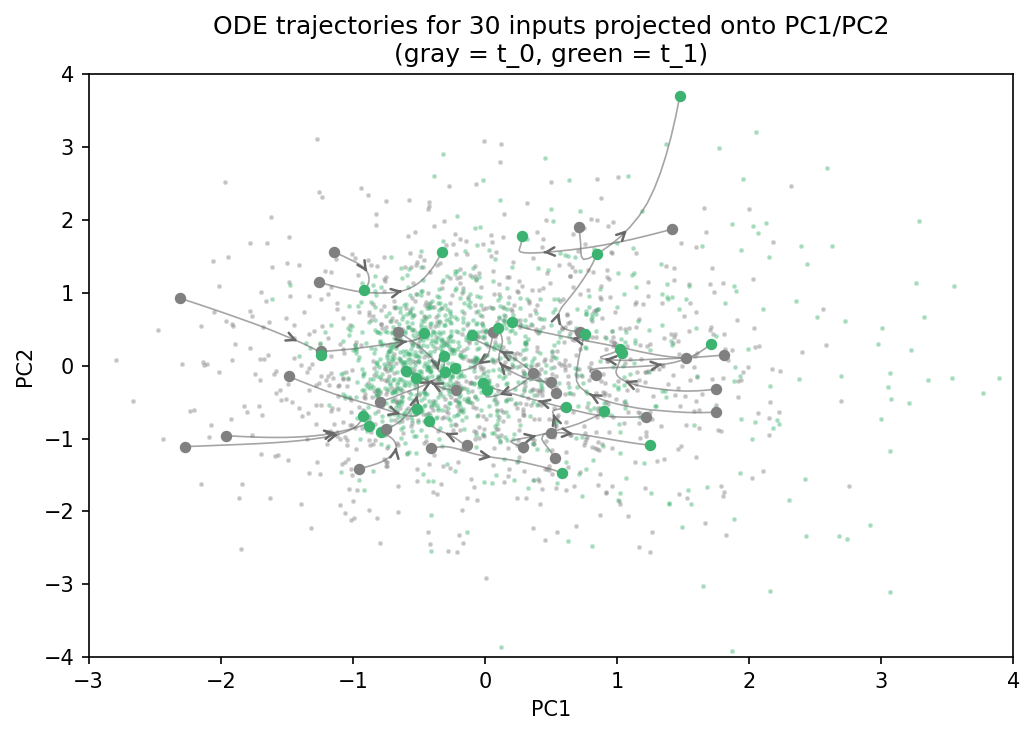

In [12]:
N_TRAJ = 30
noise_small = torch.randn(N_TRAJ, STATE_DIM)  # pure random Gaussian

model.vf.eval()
with torch.no_grad():
    traj = model.predict_trajectory(noise_small, n_steps=20)

traj_np = traj.numpy()  # (n_steps, N_TRAJ, 50)

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)

# Background: all noise + all generated points (small and faint)
ax.scatter(noise_np[:, 0], noise_np[:, 1], s=2, alpha=0.3, color="gray")
ax.scatter(gen_np[:, 0], gen_np[:, 1], s=2, alpha=0.3, color="mediumseagreen")

# Trajectories for the 30 sampled cells
mid = traj_np.shape[0] // 2
for i in range(N_TRAJ):
    ax.plot(traj_np[:, i, 0], traj_np[:, i, 1], lw=0.8, alpha=0.6, color="dimgray")
    ax.annotate(
        "",
        xy=(traj_np[mid + 1, i, 0], traj_np[mid + 1, i, 1]),
        xytext=(traj_np[mid, i, 0], traj_np[mid, i, 1]),
        arrowprops={"arrowstyle": "->", "color": "dimgray", "lw": 1.2},
    )
    ax.scatter(traj_np[0, i, 0], traj_np[0, i, 1], s=20, color="gray", zorder=5)
    ax.scatter(traj_np[-1, i, 0], traj_np[-1, i, 1], s=20, color="mediumseagreen", zorder=5)

ax.set_xlim(-3, 4)
ax.set_ylim(-4, 4)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"ODE trajectories for {N_TRAJ} inputs projected onto PC1/PC2\n(gray = t_0, green = t_1)")
plt.tight_layout()
plt.show()

### What's next?

| Tutorial | What it introduces |
|---|---|
| [`200_conditional_fm_synthetic.ipynb`](200_conditional_fm_synthetic.ipynb) | Conditional FM on synthetic data — one model, two transport maps |
| [`210_conditional_fm_pbmc.ipynb`](210_conditional_fm_pbmc.ipynb) | Conditional FM on real PBMC data with 90 cytokine conditions and ESM2 embeddings |